# Table of Contents

- [Before your start:](#before-your-start:)
  - [0.1 Read the README.md file](#before-your-start:)
  - [0.2 Introduction](#before-your-start:)
  - [0.3 Dataset](#dataset)
  - [0.4 Libraries](#libraries)

- [Challenge 1 - Exploratory Data Analysis (EDA)](#challenge-1---exploratory-data-analysis-(eda))
  - [1.1 Bivariate analysis](#explore-the-data-from-an-bird's-eye-view.)
  - [1.2 Evaluate correlations between columns](#evaluate-correlations-between-columns)
  - data selection
  - data cleaning
  - data preprocessing
  - imbalanced dataset

solo los titulos con hupervinculo. el resto sin.






- [Challenge 2 - Data Preprocessing](#challenge-2---remove-column-collinearity)

- [Challenge 3 - Handle Missing Values](#challenge-3---handle-missing-values)
  - [3.1 Handle missing values](#handle-missing-values)
  - [3.2 Examine the number of missing values in each column](#examine-the-number-of-missing-values-in-each-column)

- [Challenge 4 - Handle WHOIS Categorical Data](#challenge-4---handle-whois-categorical-data)
  - [4.1 Fix the country values](#fix-the-country-values)
  - [4.2 Consolidate low-frequency values](#consolidate-low-frequency-values)
  - [4.3 Keep the top 10 values and label the rest as OTHER](#keep-the-top-10-values-and-label-the-rest-as-other)
  - [4.4 Drop unnecessary columns](#drop-unnecessary-columns)

- [Challenge 5 - Handle Remaining Categorical Data & Convert to Ordinal](#challenge-5---handle-remaining-categorical-data--convert-to-ordinal)
  - [5.1 Handle URL](#handle-url)
  - [5.2 Examine unique values of CHARSET](#examine-unique-values-of-charset)
  - [5.3 Convert categorical variables to ordinal](#convert-categorical-variables-to-ordinal)

- [Challenge 6 - Modeling, Prediction, and Evaluation](#challenge-6---modeling-prediction-and-evaluation)
  - [6.1 Train and compare different models](#train-and-compare-different-models)
  - [6.2 Decision Tree Classifier](#decision-tree-classifier)
  - [6.3 Decision Tree Classifier with max_depth=5](#decision-tree-classifier-with-max_depth5)

- [Bonus Challenge - Feature Scaling](#bonus-challenge---feature-scaling)

# Before your start:
##### Read the README.md file
##### Introduction
In this notebook, we will explore a dataset that describes vehicle insurance claims with different features and labels them either fraudulent or non-fraudulent. We will use supervised learning algorithms to figure out what feature patterns fraudulent claims are likely to have and use our model to predict fraudulent claims. The purpose is to provide a detailed explanation of the process of building a classification model.

##### Dataset
*Source: [kaggle - vehicle-claim-fraud-detection](https://www.kaggle.com/datasets/shivamb/vehicle-claim-fraud-detection)*

Definition of Features

* **Month**: The month in which the insurance claim was made.
* **WeekOfMonth**: The week of the month in which the insurance claim was made.
* **DayOfWeek**: The day of the week on which the insurance claim was made. 
* **Make**: The manufacturer of the vehicle involved in the claim. 
* **AccidentArea**: The area where the accident occurred (e.g., urban, rural).
* **DayOfWeekClaimed**: The day of the week on which the insurance claim was processed. 
* **MonthClaimed**: The month in which the insurance claim was processed.
* **WeekOfMonthClaimed**: The week of the month in which the insurance claim was processed. 
* **Sex**: The gender of the policyholder.
* **MaritalStatus**: The material status of the policyholder. 
* **Age**: The age of the policyholder.
* **Fault**: Indicates whether the policyholder was at fault in the accident.
* **PolicyType**: The type of insurance policy (e.g., comprehensive, third-party).
* **VehicleCategory**: The category of the vehicle (e.g., sedan, SUV).
* **VehiclePrice**: The price of vehicle.
* **PolicyNumber**: The unique identifier for the insurance policy.
* **RepNumber**: The unique identifier for the insurance representative handling the claim. 
* **Deductible**: The amount that the policy holder must pay out of pocket before the insurance company pays the remaining costs.
* **DriverRating**: The rating of the driver, often based on driving history or other factors.
* **Days_Policy_Accident**: The number of days since the policy was issued until the accident occurred.
* **Days_Policy_Claim**: The number of days since the policy was issued until the claim was made.
* **PastNumberOfClaims**: The number of claims previously made by the policyholder.
* **AgeOfVehicle**: The age of the vehicle involved in the claim.
* **AgeOfPolicyHolder**: The age of the policyholder.
* **PoliceReportFiled**: Indicates whether a police report was filed for the accident.
* **WitnessPresent**: Indicates whether a witness was present at the scene of the accident.
* **AgentType**: The type of insurance agent handling the policy (e.g., internal, external) 
* **NumberOfSuppliments**: The number of supplementary documents or claims related to the main claim, categorized into ranges.
* **AddressChange_Claim**: Indicates whether the address of the policyholder was changed at the time of the claim, categorized into ranges.
* **NumberOfCars**: The number of cars insured under the policy, categorized into ranges.
* **Year**: The year in which the claim was made or processed. 
* **BasePolicy**: The base policy type (e.g., Liability, Collision, All Perils). 

Definition of Target

* **FraudFound_P**: Indicates whether fraud was detected in the insurance claim.

##### Libraries

In [347]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# Visualization - Plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Encoding
from sklearn.preprocessing import LabelEncoder

# Handling Outliers
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# SMOTE Oversampling
from imblearn.over_sampling import SMOTE

# VarianceThreshold
from sklearn.feature_selection import VarianceThreshold

# RFECV
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# Machine Learning - Preparation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix

# Machine Learning - Algorithm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb

# Machine Learning - Optuna
#import optuna
#from optuna.samplers import TPESampler

# Machine Learning - Feature Importance
from sklearn.inspection import permutation_importance

# Challenge 1 - Exploratory Data Analysis (EDA)

In [299]:
raw_data = pd.read_csv('data/fraud_oracle.csv')
raw_data.shape

(15420, 33)

In [147]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [80]:
raw_data.isna().sum()

Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64

In [79]:
raw_data.duplicated().sum()

np.int64(0)

1. There are no missing or duplicate values

In [85]:
raw_data.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [106]:
def summarize(DataFrame):
    
    summary = pd.DataFrame()
    
    # Data Type
    summary['Data Type'] = DataFrame.dtypes
    # N Unique
    summary['N Unique'] = DataFrame.nunique()
    # Unique
    summary['Unique'] = DataFrame.apply(lambda x: x.unique().tolist())
    # Max
    summary['Max'] = DataFrame.apply(lambda x: x.max() if pd.api.types.is_numeric_dtype(x) else '-')
    # Min
    summary['Min'] = DataFrame.apply(lambda x: x.min() if pd.api.types.is_numeric_dtype(x) else '-')
    
    # Measures of Central Tendency: Mean, Median, Mode 
    summary['Mean'] = DataFrame.apply(lambda x: round(x.mean(), 2) if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Median'] = DataFrame.apply(lambda x: x.median() if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Mode'] = DataFrame.apply(lambda x: x.mode().iloc[0] if not x.mode().empty else '-')
    
    # Measures of Dispersion: Range, Variance, Standard Deviation
    summary['Range'] = DataFrame.apply(lambda x: x.max() - x.min() if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Variance'] = DataFrame.apply(lambda x: x.var() if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Standard Deviation'] = DataFrame.apply(lambda x: x.std() if pd.api.types.is_numeric_dtype(x) else '-')
    
    # Measures of Shape: Skewness, Kurtosis
    summary['Skewness'] = DataFrame.apply(lambda x: round(x.skew(), 2) if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Kurtosis'] = DataFrame.apply(lambda x: round(x.kurt(), 2) if pd.api.types.is_numeric_dtype(x) else '-')
    
    return summary

In [131]:
summary = summarize(raw_data)
summary

,Data Type,N Unique,Unique,Max,Min,Mean,Median,Mode,Range,Variance,Standard Deviation,Skewness,Kurtosis
Month,object,12,"[Dec, Jan, Oct, Jun, Feb, Nov, Apr, Mar, Aug, ...",-,-,-,-,Jan,-,-,-,-,-
WeekOfMonth,int64,5,"[5, 3, 2, 4, 1]",5,1,2.79,3.0,3,4,1.657876,1.287585,0.12,-1.1
DayOfWeek,object,7,"[Wednesday, Friday, Saturday, Monday, Tuesday,...",-,-,-,-,Monday,-,-,-,-,-
Make,object,19,"[Honda, Toyota, Ford, Mazda, Chevrolet, Pontia...",-,-,-,-,Pontiac,-,-,-,-,-
AccidentArea,object,2,"[Urban, Rural]",-,-,-,-,Urban,-,-,-,-,-
DayOfWeekClaimed,object,8,"[Tuesday, Monday, Thursday, Friday, Wednesday,...",-,-,-,-,Monday,-,-,-,-,-
MonthClaimed,object,13,"[Jan, Nov, Jul, Feb, Mar, Dec, Apr, Aug, May, ...",-,-,-,-,Jan,-,-,-,-,-
WeekOfMonthClaimed,int64,5,"[1, 4, 2, 3, 5]",5,1,2.69,3.0,2,4,1.585371,1.259115,0.16,-1.09
Sex,object,2,"[Female, Male]",-,-,-,-,Male,-,-,-,-,-
MaritalStatus,object,4,"[Single, Married, Widow, Divorced]",-,-,-,-,Married,-,-,-,-,-


2. "PolicyNumber" is merely an identification number. Let's drop it.
3. Features related to "date" seems to have similar distributions, don`t need them all. Let's drop it.
4. "Age" and "AgeOfPolicyHolder" have the same information. Let`s drop it.
5. The minimum value of "Age" is 0, doesn't make sense. Should decide what to do with it later.
6. The features "Sex", "PoliceReportFiled", and "WitnessPresent" are actually Boolen Types. Should be converted to 0 or 1.
7. The features "AccidentalArea", "Fault", and "AgentType" each have only two unique values. Can also be converted to 0 or 1.
8. Strictly speaking, among all the features, only Age is a numeric variable. The rest can be interpreted as categorical variables. Instead of calculating Pearson or Spearman correlations, we will calculate Chi Square and Cramer's V.

In [300]:
clean_data_1 = raw_data.drop(columns=["PolicyNumber","WeekOfMonth","DayOfWeek","DayOfWeekClaimed","MonthClaimed","WeekOfMonthClaimed","AgeOfPolicyHolder"])
clean_data_1.head()

,Month,Make,AccidentArea,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,Honda,Urban,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,12,300,1,more than 30,more than 30,none,3 years,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,Honda,Urban,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,15,400,4,more than 30,more than 30,none,6 years,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,Honda,Urban,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,7,400,3,more than 30,more than 30,1,7 years,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,Toyota,Rural,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,400,2,more than 30,more than 30,1,more than 7,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,Honda,Urban,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,3,400,1,more than 30,more than 30,none,5 years,No,No,External,none,no change,1 vehicle,1994,Collision


### Feature "Age"

In [301]:
fraud = raw_data[raw_data["FraudFound_P"] == 1]
nofraud = raw_data[raw_data["FraudFound_P"] != 1]

In [302]:
fraud_percentage_age = (
    raw_data.groupby("Age")["FraudFound_P"]
    .mean()
    .mul(100)
    .reindex(range(0, 81))
)

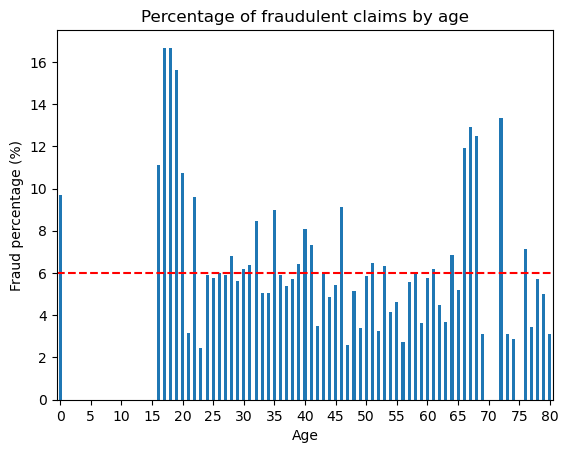

In [303]:
fraud_percentage_age.plot(kind="bar")

plt.xlabel("Age")
plt.ylabel("Fraud percentage (%)")
plt.title("Percentage of fraudulent claims by age")

plt.xticks(
    ticks=range(0, 81, 5),
    labels=range(0, 81, 5),
    rotation=0
)

plt.axhline(y=6, linestyle="--", color="red")

plt.show()

Fraud is most frequently detected among teenagers and retired seniors. Teenagers have weak financial power as they have not yet started their economic activities, and retired seniors experience weakened financial power post-retirement. Considering these points, there seems to be a correlation between financial power and fraud.

Text(0.5, 1.0, 'Age distribution')

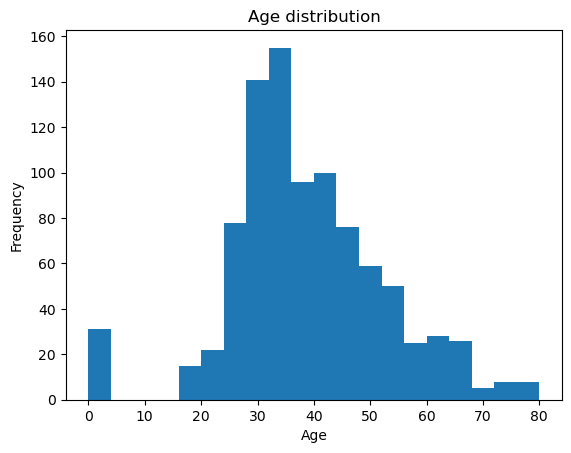

In [257]:
plt.hist(fraud["Age"], bins=20)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age distribution")

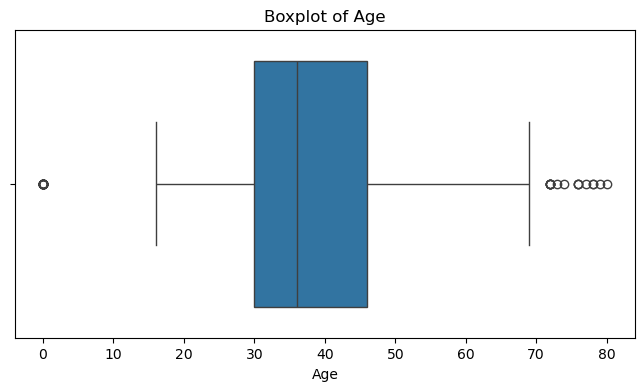

In [258]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=fraud["Age"])

plt.title("Boxplot of Age")
plt.show()

In [304]:
(fraud["Age"]==0).sum()

np.int64(31)

Many claims with "Age" = 0, we can't drop them. Since it is a numerical feature, we replace it with a measure of central tendency.
The median is more robust to outliers because extreme values have little effect on it.
The mean can be pulled up or down by extreme ages, making the imputed value less representative.

In [308]:
median_age = raw_data.Age[raw_data["Age"] != 0].median()
mean_age = raw_data.Age[raw_data["Age"] != 0].mean()
print(median_age)
print(mean_age)

39.0
40.700331125827816


In [307]:
clean_data_1.loc[clean_data_1["Age"] == 0, "Age"] = median_age

### Feature "Sex"

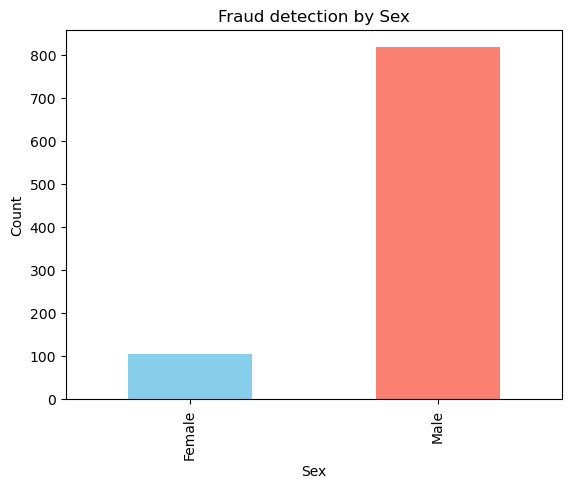

In [332]:
fraud["Sex"].value_counts().sort_values().plot(kind="bar", color=["skyblue", "salmon"])

plt.xlabel("Sex")
plt.ylabel("Count")
plt.title("Fraud detection by Sex")
plt.show()

These results suggest that males are significantly more likely to be involved in detected fraud cases compared to females. However, this should be interpreted with some caution, as there are also more male drivers than female drivers in the dataset. As a result, males generate a higher number of claims overall, which can naturally lead to a higher absolute number of detected fraud cases.

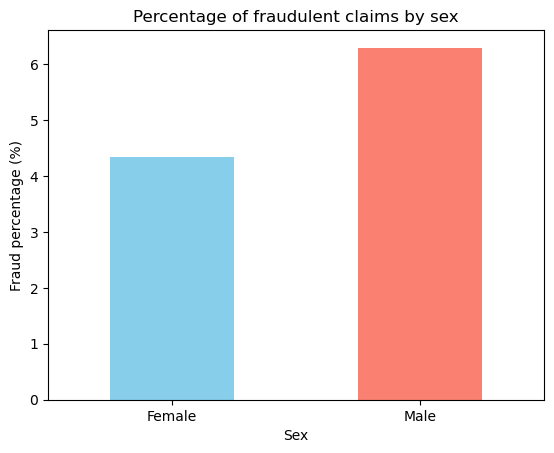

In [333]:
fraud_percentage_sex = (
    raw_data.groupby("Sex")["FraudFound_P"]
    .mean()
    .mul(100)
)
fraud_percentage_sex.plot(kind="bar", color=["skyblue", "salmon"])

plt.xlabel("Sex")
plt.ylabel("Fraud percentage (%)")
plt.title("Percentage of fraudulent claims by sex")
plt.xticks(rotation=0)
plt.show()

After studying percentages , males have a higher fraud rate.

### Feature "Make"

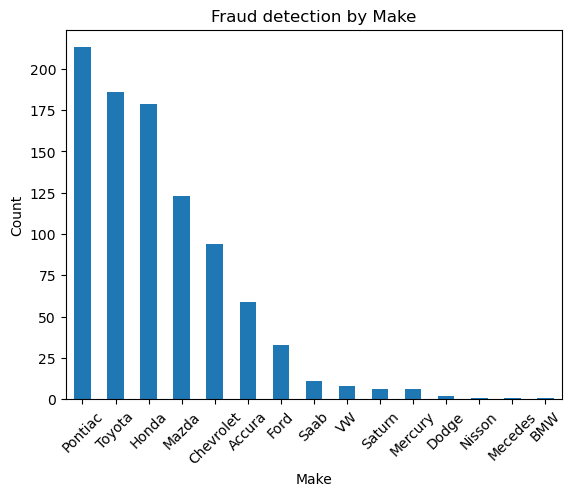

In [ ]:
fraud["Make"].value_counts().plot(kind="bar")

plt.xlabel("Make")
plt.ylabel("Count")
plt.title("Fraud detection by Make")
plt.xticks(rotation=45)
plt.show()

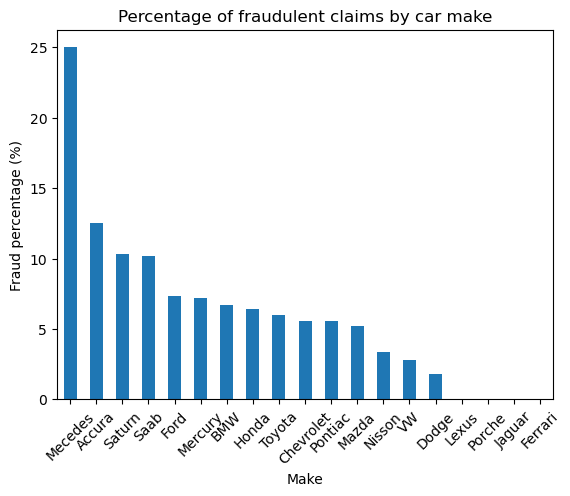

In [ ]:
fraud_percentage_make = (
    raw_data.groupby("Make")["FraudFound_P"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

fraud_percentage_make.plot(kind="bar")

plt.xlabel("Make")
plt.ylabel("Fraud percentage (%)")
plt.title("Percentage of fraudulent claims by car make")
plt.xticks(rotation=45)
plt.show()

In [188]:
make_analysis = raw_data.groupby("Make").agg(
    Total_Claims=("FraudFound_P", "count"),
    Fraudulent_Claims=("FraudFound_P", "sum"),
    Fraud_Percentage=("FraudFound_P", "mean")
)

make_analysis["Fraud_Percentage"] *= 100

make_analysis.sort_values(
    "Fraud_Percentage",
    ascending=False
)

,Total_Claims,Fraudulent_Claims,Fraud_Percentage
Make,,,
Mecedes,4,1,25.000000
Accura,472,59,12.500000
Saturn,58,6,10.344828
Saab,108,11,10.185185
Ford,450,33,7.333333
Mercury,83,6,7.228916
BMW,15,1,6.666667
Honda,2801,179,6.390575
Toyota,3121,186,5.959628


For the Make variable, it is more informative to analyze the percentage of fraudulent claims within each car brand rather than only the absolute number of fraudulent claims. A brand may have a high number of fraud cases simply because it has a larger number of total claims. By calculating the fraud rate for each make, we can compare brands more fairly and identify whether certain car brands are associated with a higher proportion of fraudulent claims.

However, fraud percentages should be interpreted carefully when a car make has very few observations. For example, Mercedes shows a fraud rate of 25%, but this is based on only 4 total claims, with 1 fraudulent case. Because of this small sample size, the percentage is not very reliable and may exaggerate the apparent fraud risk compared with brands that have a much larger number of claims.

On the other hand, the Porche, Lexus, Jaguar, Ferrari owners have never been reported for fraud; all the four make are "High-End"

### Chi-square tests
Tests the independence of two categorical variables by comparing observed frequencies to expected frequencies.

- The chi-square test is a statistical test used to **determine whether there is a significant association between two categorical variables**.
- Interpretation: if p-value < 0.05, this suggests that there is a significant association between the categorical variables. P-value >= 0.05, indicates that there is not enough evidence to conclude a significant association between the variables.


In [311]:
from scipy.stats import chi2_contingency
crosstab_result = pd.crosstab(raw_data.PolicyType,raw_data.BasePolicy)
crosstab_result

BasePolicy,All Perils,Collision,Liability
PolicyType,,,
Sedan - All Perils,4087,0,0
Sedan - Collision,0,5584,0
Sedan - Liability,0,0,4987
Sport - All Perils,22,0,0
Sport - Collision,0,348,0
Sport - Liability,0,0,1
Utility - All Perils,340,0,0
Utility - Collision,0,30,0
Utility - Liability,0,0,21


In [266]:
_, chi2_pvalue, _, _  = chi2_contingency(crosstab_result)
a,b,c,d=chi2_contingency(crosstab_result)
float(chi2_pvalue)

0.0

In [267]:
float(chi2_pvalue) < 0.05

True

p-value< 0.05, we reject the hyphoteshis that the two categorical features are independet, this implies that there's a significant association between PolicyType and BasePolicy. we do have correlation between them

### Cramér's V

While the Chi-square test informs us about the independence of two categorical variables, Cramér's V measures the strength of the association between them.

- Cramer's V is a measure of association used to **quantify the strength of the relationship between categorical variables**.
- Interpretation: Cramer's V ranges from 0 to 1, where **0 indicates no association, and 1 represents a perfect association between the variables**. A higher value of Cramer's V indicates a stronger relationship between the categorical variables.


In [268]:
from scipy.stats.contingency import association
# Computing the association between variables in 'crosstab_result' using the "cramer" method
association(crosstab_result, method='cramer')

0.9999999999999999

### Cramér’s V Interpretation Guide (Cohen's Conventions)

| Cramér’s V | Strength of Association   |
|------------|----------------------------|
| 0.00–0.10  | Negligible / Very Weak     |
| 0.10–0.20  | Weak                       |
| 0.20–0.30  | Moderate                   |
| 0.30–0.50  | Strong                     |
| > 0.50     | Very Strong                |


Very strong relationship between them. Final decision, to drop PolicyType.

In [312]:
clean_data_1.drop(columns=["PolicyType"], inplace=True)

In [314]:
clean_data_1.head()

,Month,Make,AccidentArea,Sex,MaritalStatus,Age,Fault,VehicleCategory,VehiclePrice,FraudFound_P,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,Honda,Urban,Female,Single,21,Policy Holder,Sport,more than 69000,0,12,300,1,more than 30,more than 30,none,3 years,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,Honda,Urban,Male,Single,34,Policy Holder,Sport,more than 69000,0,15,400,4,more than 30,more than 30,none,6 years,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,Honda,Urban,Male,Married,47,Policy Holder,Sport,more than 69000,0,7,400,3,more than 30,more than 30,1,7 years,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,Toyota,Rural,Male,Married,65,Third Party,Sport,20000 to 29000,0,4,400,2,more than 30,more than 30,1,more than 7,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,Honda,Urban,Female,Single,27,Third Party,Sport,more than 69000,0,3,400,1,more than 30,more than 30,none,5 years,No,No,External,none,no change,1 vehicle,1994,Collision


Days_Policy_Accident vs Days_Policy_Claim

In [ ]:
clean_data_1.Days_Policy_Claim.value_counts()

Days_Policy_Claim
more than 30    15342
15 to 30           56
8 to 15            21
none                1
Name: count, dtype: int64

In [ ]:
clean_data_1.Days_Policy_Accident.value_counts()

Days_Policy_Accident
more than 30    15247
none               55
8 to 15            55
15 to 30           49
1 to 7             14
Name: count, dtype: int64

In [283]:
crosstab_result2 = pd.crosstab(clean_data_1.Days_Policy_Accident,clean_data_1.Days_Policy_Claim)
_, chi2_pvalue, _, _  = chi2_contingency(crosstab_result2)
a,b,c,d=chi2_contingency(crosstab_result2)
float(chi2_pvalue)

0.0

In [282]:
association(crosstab_result2, method='cramer')

0.4073286752092501

Although Days_Policy_Accident and Days_Policy_Claim are strongly related, we should not automatically drop either variable because they represent different stages of the insurance claim process. Days_Policy_Accident measures the time between policy inception and the accident, while Days_Policy_Claim measures the time between policy inception and the claim being reported. From a fraud detection perspective, both can contain useful information, since an accident occurring shortly after policy inception and a delayed claim submission may indicate different types of suspicious behavior. Therefore, even with a strong relationship between them, keeping both variables can preserve potentially relevant predictive information for the model.

# Data preprocessing

Label Encoding

In [315]:
binary_columns = [col for col in clean_data_1.columns if clean_data_1[col].nunique() == 2 and col != 'FraudFound_P']
binary_columns

['AccidentArea',
 'Sex',
 'Fault',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType']

In [316]:
le = LabelEncoder()

for col  in binary_columns:
    clean_data_1[col] = le.fit_transform(clean_data_1[col])
    print('Label Mapping: ', dict(zip(le.classes_, le.transform(le.classes_))))

Label Mapping:  {'Rural': np.int64(0), 'Urban': np.int64(1)}
Label Mapping:  {'Female': np.int64(0), 'Male': np.int64(1)}
Label Mapping:  {'Policy Holder': np.int64(0), 'Third Party': np.int64(1)}
Label Mapping:  {'No': np.int64(0), 'Yes': np.int64(1)}
Label Mapping:  {'No': np.int64(0), 'Yes': np.int64(1)}
Label Mapping:  {'External': np.int64(0), 'Internal': np.int64(1)}


In [317]:
vehicleprice_label = {'less than 20000': 0, '20000 to 29000': 1,  '30000 to 39000': 2, '40000 to 59000': 3, '60000 to 69000': 4, 'more than 69000': 5}
ageofvehicle_label = {'new': 0, '2 years': 1, '3 years': 2, '4 years': 3, '5 years': 4, '6 years': 5, '7 years': 6, 'more than 7': 7}
dayspolacc_label = {'none': 0, '1 to 7': 1, '8 to 15': 2, '15 to 30': 3, 'more than 30': 4}
dayspolcla_label = {'none': 0, '8 to 15': 2, '15 to 30': 3, 'more than 30': 4}
month_label = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
pastnumcla_label = {'none': 0, '1': 1, '2 to 4': 2, 'more than 4': 3}
numberofsup_label = {'none': 0, '1 to 2': 1, '3 to 5': 2, 'more than 5': 3}
addresschange_label = {'no change': 0, 'under 6 months': 1, '1 year': 2, '2 to 3 years': 3, '4 to 8 years': 4}
numberofcars_label = {'1 vehicle': 0, '2 vehicles': 1, '3 to 4': 2, '5 to 8': 3, 'more than 8': 4}

In [318]:
columns_labels = {
    'VehiclePrice': vehicleprice_label,
    'AgeOfVehicle': ageofvehicle_label,
    'Days_Policy_Accident': dayspolacc_label,
    'Days_Policy_Claim': dayspolcla_label,
    'Month': month_label,
    'PastNumberOfClaims': pastnumcla_label,
    'NumberOfSuppliments': numberofsup_label,
    'AddressChange_Claim': addresschange_label,
    'NumberOfCars': numberofcars_label
}

for column, label_map in columns_labels.items():
    clean_data_1[column] = clean_data_1[column].map(label_map)


One hot encoding

In [323]:
clean_data_1.columns

Index(['Month', 'Make', 'AccidentArea', 'Sex', 'MaritalStatus', 'Age', 'Fault',
       'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'RepNumber',
       'Deductible', 'DriverRating', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year',
       'BasePolicy'],
      dtype='object')

In [327]:
clean_data_2 = pd.get_dummies(clean_data_1, columns=["Make","MaritalStatus","VehicleCategory","BasePolicy"], drop_first=True)

In [328]:
clean_data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Month                    15420 non-null  int64
 1   AccidentArea             15420 non-null  int64
 2   Sex                      15420 non-null  int64
 3   Age                      15420 non-null  int64
 4   Fault                    15420 non-null  int64
 5   VehiclePrice             15420 non-null  int64
 6   FraudFound_P             15420 non-null  int64
 7   RepNumber                15420 non-null  int64
 8   Deductible               15420 non-null  int64
 9   DriverRating             15420 non-null  int64
 10  Days_Policy_Accident     15420 non-null  int64
 11  Days_Policy_Claim        15420 non-null  int64
 12  PastNumberOfClaims       15420 non-null  int64
 13  AgeOfVehicle             15420 non-null  int64
 14  PoliceReportFiled        15420 non-null  int64
 15  Wi

### Target Balance

In [ ]:
target_count = raw_data.FraudFound_P.value_counts().reset_index()
target_count.columns = ["FraudFound_P", "Count"]
target_count

,FraudFound_P,Count
0,0,14497
1,1,923


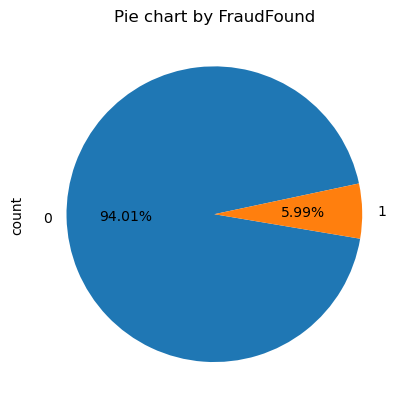

In [ ]:
fraud_freq = raw_data.FraudFound_P.value_counts()
fraud_freq.plot.pie(autopct='%1.2f%%' ,startangle=12)
plt.title("Pie chart by FraudFound")
plt.show()

The Target Variable "Fraud_Found_P" is highly imbalanced

Issues Caused by Imbalanced Target Variable

Model Bias: The model may become biased towards the majority class, leading to poor performance on the minority class.

Misleading Metrics: Metrics like accuracy can be misleading, as high accuracy can be achieved by simply predicting the majority class.

Solutions: 
- use precision-recall and f1 score metrics.
  In this imbalanced dataset, we will use **recall and precision** as our main evaluation metrics, with a stronger focus on **recall**. In our case, a false negative for a fraudulent claim is more costly than a false positive. In other words, if the model predicts that a claim is not fraudulent when it actually is, the financial impact can be significant. This is more critical than incorrectly flagging a legitimate claim as fraudulent, which would mainly require further investigation.

- balance the dataset random undersampling.


# Modeling, Prediction and Evaluation

models to try:

Logistic regression, KNN Clasiffier, Random forest, xgboost, gradient boost

### This is an example to know the feacture importance using a ML model

In [345]:
X = clean_data_2._get_numeric_data().drop('FraudFound_P', axis=1)
y = clean_data_2.FraudFound_P

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13, stratify=y)

In [354]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "GradientBoost": GradientBoostingClassifier(),
    "XGBoost": xgb.XGBClassifier()
    #"XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"\n{name}:\n")
    print(confusion_matrix(y_test, preds))
    print(recall_score(y_test, preds))

c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression:

[[2899    0]
 [ 185    0]]
0.0

KNN:

[[2881   18]
 [ 180    5]]
0.02702702702702703

Random Forest:

[[2895    4]
 [ 180    5]]
0.02702702702702703

GradientBoost:

[[2898    1]
 [ 178    7]]
0.03783783783783784

XGBoost:

[[2881   18]
 [ 166   19]]
0.10270270270270271


In [357]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=13,
        #C=5,
        #class_weight= balanced,
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=3,
        n_jobs= -1
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        criterion= "entropy", #log_loss
        max_depth=10,
        max_features='log2',
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=13,
        #class_weight= balanced
    ),
    "GradientBoosting": GradientBoostingClassifier(
        #loss,
        learning_rate=0.05,
        n_estimators=200,
        #criterion,
        random_state=13,
        max_features=5
    ),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"\n{name}:\n")
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds))

c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: Un


Logistic Regression:

[[2899    0]
 [ 185    0]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.00      0.00      0.00       185

    accuracy                           0.94      3084
   macro avg       0.47      0.50      0.48      3084
weighted avg       0.88      0.94      0.91      3084


KNN:

[[2859   40]
 [ 173   12]]
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      2899
           1       0.23      0.06      0.10       185

    accuracy                           0.93      3084
   macro avg       0.59      0.53      0.53      3084
weighted avg       0.90      0.93      0.91      3084


Random Forest:

[[2899    0]
 [ 185    0]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.00      0.00      0.00       185

    accuracy                           0.94      3084


c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



GradientBoosting:

[[2899    0]
 [ 185    0]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.00      0.00      0.00       185

    accuracy                           0.94      3084
   macro avg       0.47      0.50      0.48      3084
weighted avg       0.88      0.94      0.91      3084



c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yoanl\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yoanl\anaconda3\Lib


XGBoost:

[[2881   18]
 [ 166   19]]
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      2899
           1       0.51      0.10      0.17       185

    accuracy                           0.94      3084
   macro avg       0.73      0.55      0.57      3084
weighted avg       0.92      0.94      0.92      3084



In [18]:
xgb_model = xgb.XGBClassifier()

In [19]:
xgb_model.fit(X,y)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [20]:
sort_idx = xgb_model.feature_importances_.argsort()

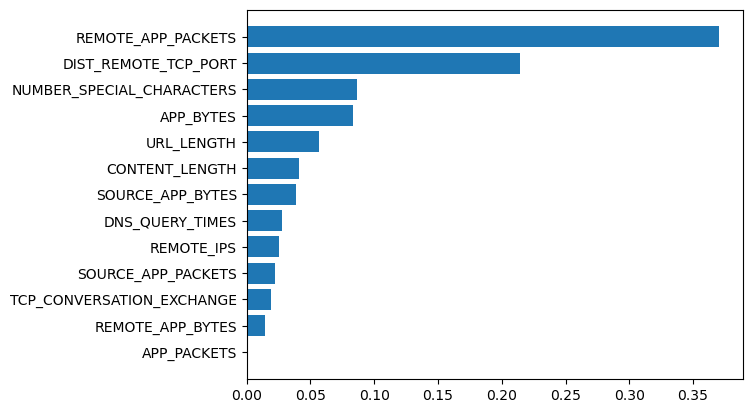

In [21]:
plt.barh(X.columns[sort_idx],xgb_model.feature_importances_[sort_idx])
plt.show();

    In the previous plot we can see the feactures with lower weight in the dataset.

# Challenge 6 - Modeling, Prediction, and Evaluation

We'll start off this section by splitting the data to train and test. **Name your 4 variables `X_train`, `X_test`, `y_train`, and `y_test`. Select 80% of the data for training and 20% for testing.**

In [59]:
from sklearn.model_selection import train_test_split

# Your code here:
X = website_dummy.drop('Type', axis=1)
y = website_dummy.Type
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### In this lab, we will try two different models and compare our results.

The first model we will use in this lab is logistic regression. We have previously learned about logistic regression as a classification algorithm. In the cell below, load `LogisticRegression` from scikit-learn and initialize the model.

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
from sklearn.linear_model import LogisticRegression 

In [62]:
model_logreg = LogisticRegression()


Next, fit the model to our training data. We have already separated our data into 4 parts. Use those in your model.

In [63]:
# Your code here:
model_logreg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


finally, import `confusion_matrix` and `accuracy_score` from `sklearn.metrics` and fit our testing data. Assign the fitted data to `y_pred` and print the confusion matrix as well as the accuracy score

In [64]:
# Your code here:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [65]:
y_pred = model_logreg.predict(X_test_scaled)
print("Logistic Regression Report:\n", classification_report(y_test, y_pred))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96       224
           1       0.92      0.39      0.55        28

    accuracy                           0.93       252
   macro avg       0.92      0.69      0.76       252
weighted avg       0.93      0.93      0.92       252



In [66]:
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.9285714285714286
[[223   1]
 [ 17  11]]


What are your thoughts on the performance of the model? Write your conclusions below.

### Your conclusions here:
    The model is working fine but it have many errors in Type 2, it says that the model predict a non malicious web like a malicious web


The model is very good at detecting non malicious(class 0) web as it only predicted 1 non-malicious web as malicious(class 1) out of the 224. However it is not good at predicting malicious web as it predicted 17 out of 28 malicious web as non malicious while they were infact malicious. It can be observed by the recall value of the class 1 which is only 0.39

#### Our second algorithm is is DecisionTreeClassifier

Though is it not required, we will fit a model using the training data and then test the performance of the model using the testing data. Start by loading `DecisionTreeClassifier` from scikit-learn and then initializing and fitting the model. We'll start off with a model where max_depth=3

In [67]:
# Your code here:
from sklearn.tree import DecisionTreeClassifier

In [68]:
model_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

In [69]:
model_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


To test your model, compute the predicted probabilities, decide 0 or 1 using a threshold of 0.5 and print the confusion matrix as well as the accuracy score (on the test set!)

In [70]:
y_prob_tree = model_tree.predict_proba(X_test)[:, 1]

y_pred_thresh_tree = (y_prob_tree >= 0.5).astype(int)

In [71]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_thresh_tree))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_thresh_tree))

Decision Tree Accuracy: 0.9246031746031746
Decision Tree Confusion Matrix:
 [[223   1]
 [ 18  10]]


#### We'll create another DecisionTreeClassifier model with max_depth=5. 
Initialize and fit the model below and print the confusion matrix and the accuracy score.

In [72]:
# Your code here:
model_tree2 = DecisionTreeClassifier(max_depth=5, random_state=42)

In [73]:
model_tree2.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [74]:
y_prob_tree2 = model_tree2.predict_proba(X_test)[:, 1]

y_pred_thresh_tree2 = (y_prob_tree2 >= 0.5).astype(int)

In [75]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_thresh_tree2))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_thresh_tree2))

Decision Tree Accuracy: 0.9246031746031746
Decision Tree Confusion Matrix:
 [[223   1]
 [ 18  10]]


Did you see an improvement in the confusion matrix when increasing max_depth to 5? Did you see an improvement in the accuracy score? Write your conclusions below.

### Your conclusions here:


The model didnot change even after increasing the max_depth from 3 to 5. 

<!-- Add your conclusion here -->

# Bonus Challenge - Feature Scaling

Problem-solving in machine learning is iterative. You can improve your model prediction with various techniques (there is a sweetspot for the time you spend and the improvement you receive though). Now you've completed only one iteration of ML analysis. There are more iterations you can conduct to make improvements. In order to be able to do that, you will need deeper knowledge in statistics and master more data analysis techniques. In this bootcamp, we don't have time to achieve that advanced goal. But you will make constant efforts after the bootcamp to eventually get there.

However, now we do want you to learn one of the advanced techniques which is called *feature scaling*. The idea of feature scaling is to standardize/normalize the range of independent variables or features of the data. This can make the outliers more apparent so that you can remove them. This step needs to happen during Challenge 6 after you split the training and test data because you don't want to split the data again which makes it impossible to compare your results with and without feature scaling. For general concepts about feature scaling, click [here](https://en.wikipedia.org/wiki/Feature_scaling). To read deeper, click [here](https://medium.com/greyatom/why-how-and-when-to-scale-your-features-4b30ab09db5e).

In the next cell, attempt to improve your model prediction accuracy by means of feature scaling. A library you can utilize is `sklearn.preprocessing.RobustScaler` ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html)). You'll use the `RobustScaler` to fit and transform your `X_train`, then transform `X_test`. You will use logistic regression to fit and predict your transformed data and obtain the accuracy score in the same way. Compare the accuracy score with your normalized data with the previous accuracy data. Is there an improvement?

In [ ]:
escalar hay algunas comlumnas que si y eliminar 0.

SyntaxError: invalid syntax (2898842027.py, line 1)

In [ ]:
solo con important features

Rows with Age = 0 were removed because this is not a valid driver age. These observations represented only around 2.3% of the dataset, so removing them resulted in minimal data loss.

In [ ]:
# Your code here
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train["Age"] = scaler.fit_transform(X_train[["Age"]])
X_test["Age"] = scaler.transform(X_test[["Age"]])

## Comments:

Add your comments here:

We will try to balance the dataset by applying undersampling, reducing the number of non-fraudulent claims to match the number of fraudulent claims in the training dataset. After training the model, we will evaluate it on the original imbalanced test dataset to determine whether recall improves.